<h2> Visualização dos dados</h2>

In [1]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
caminho = os.path.join("viz", "grafo.json")
with open(caminho, "r", encoding="utf-8") as f:
                json_doc=json.load(f)

print(f'Ordem do grafo:{len(json_doc["nodes"])}')
print(f'Tamanho do grafo:{len(json_doc["edges"])}')

Ordem do grafo:762
Tamanho do grafo:667


In [3]:
"""

Resoluções cujos números estão ausentes.
Hipótese: São resoluções conjuntas.

"""
numeros = [int(item["Número"]) for item in json_doc["nodes"]]

esperado = set(range(1, 786))
numeros_set = set(numeros)

faltando = sorted(esperado - numeros_set)
print("Resoluções ausentes:", faltando)

Resoluções ausentes: [194, 225, 243, 244, 286, 287, 290, 311, 331, 332, 422, 428, 445, 448, 485, 486, 521, 522, 531, 566, 585, 591, 592]


In [4]:
"""

DataFrame de nós.

"""
nodes_df = pd.DataFrame(json_doc["nodes"])
nodes_df = nodes_df.rename(columns={"group": "Ano"})
nodes_df = nodes_df.rename(columns={"title": "Título"})
print(nodes_df)

    Resolução Número                                             Título  \
0      1997/1      1  Resolução nº 1, de 17 de dezembro de 1997 (REV...   
1      1997/2      2  Resolução nº 2, de 19 de dezembro de 1997 (REV...   
2      1997/3      3  Resolução nº 3, de 19 de dezembro de 1997 (REV...   
3      1997/4      4  Resolução nº 4, de 19 de dezembro de 1997 (REV...   
4      1998/5      5  Resolução nº 5, de 15 de janeiro de 1998 (REVO...   
..        ...    ...                                                ...   
757  2025/781    781   Resolução Anatel nº 781, de 15 de Agosto de 2025   
758  2025/782    782   Resolução Anatel nº 782, de 25 de agosto de 2025   
759  2025/783    783  Resolução Anatel nº 783, de 03 de setembro de ...   
760  2025/784    784  Resolução Anatel nº 784, de 07 de novembro de ...   
761  2025/785    785  Resolução Anatel nº 785, de 10 de dezembro de ...   

                Vigência    Status   Ano  
0    1997-12-22T15:26:00  Revogada  1997  
1    1997-12-

In [5]:
"""

DataFrame de arestas.

"""
edges_df = pd.DataFrame(json_doc["edges"])
edges_df= edges_df.rename(columns={ "from":"Origem"})
edges_df=edges_df.rename(columns={"to":"Destino"})
print(edges_df)

       Origem   Destino
0      1997/1  1999/197
1    1999/197  2001/270
2    2001/270  2013/612
3      1997/2  2019/708
4      1997/3  2019/708
..        ...       ...
662  2021/742  2025/772
663  2021/743  2025/777
664  2022/750  2025/777
665  2022/758  2023/762
666  2023/766  2025/772

[667 rows x 2 columns]


In [6]:
print("Top 10 de resoluções com maior número de revogações")
edges_df["Destino"].value_counts().head(10)

Top 10 de resoluções com maior número de revogações


Destino
2019/708    170
2022/752     44
2023/759     37
2017/686     36
2020/721     35
2025/777     34
2022/749     18
2022/755     16
2020/723     15
2022/757     14
Name: count, dtype: int64

In [18]:
print(f'Resoluções em vigor: {(nodes_df["Status"]=="Em vigor").sum()}')
nodes_df[nodes_df["Status"] == "Em vigor"]["Resolução"].to_csv("resolucoes.csv", index=False)

Resoluções em vigor: 95


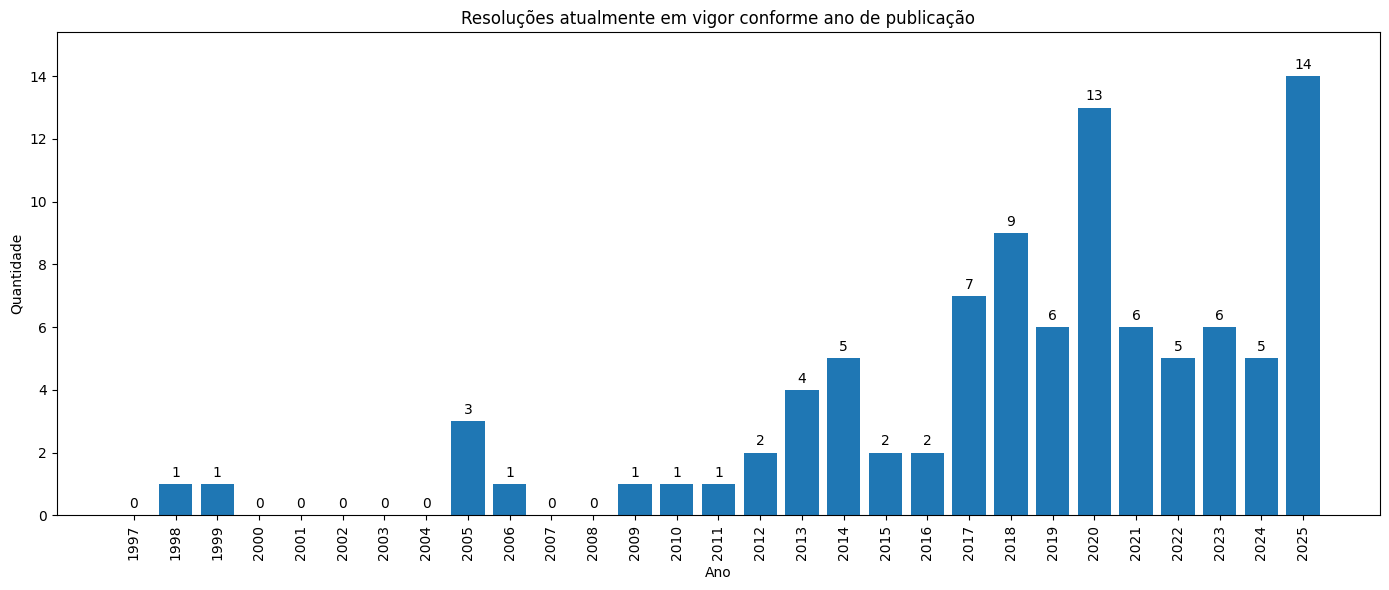

In [8]:
"""

Plotagem gráfico de barras de resoluções em vigor por ano.

"""
nodes_df["Ano"] = nodes_df["Ano"].astype(int)

nodes_vigor = nodes_df[nodes_df["Status"] == "Em vigor"]

vigor_por_ano = nodes_vigor["Ano"].value_counts()

ano_min = nodes_df["Ano"].min()
ano_max = nodes_df["Ano"].max()
anos_completos = range(ano_min, ano_max + 1)

vigor_por_ano = (
    vigor_por_ano
    .reindex(anos_completos, fill_value=0)
    .sort_index()
)


plt.figure(figsize=(14, 6))


bars = plt.bar(vigor_por_ano.index, vigor_por_ano.values)

plt.bar_label(bars, padding=3) 

plt.title("Resoluções atualmente em vigor conforme ano de publicação")
plt.xlabel("Ano")
plt.ylabel("Quantidade")
plt.xticks(anos_completos, rotation=90)

# Aumentar um pouco o limite superior do eixo Y para o número não ficar cortado
plt.ylim(0, vigor_por_ano.max() * 1.1)

plt.tight_layout()
plt.show()

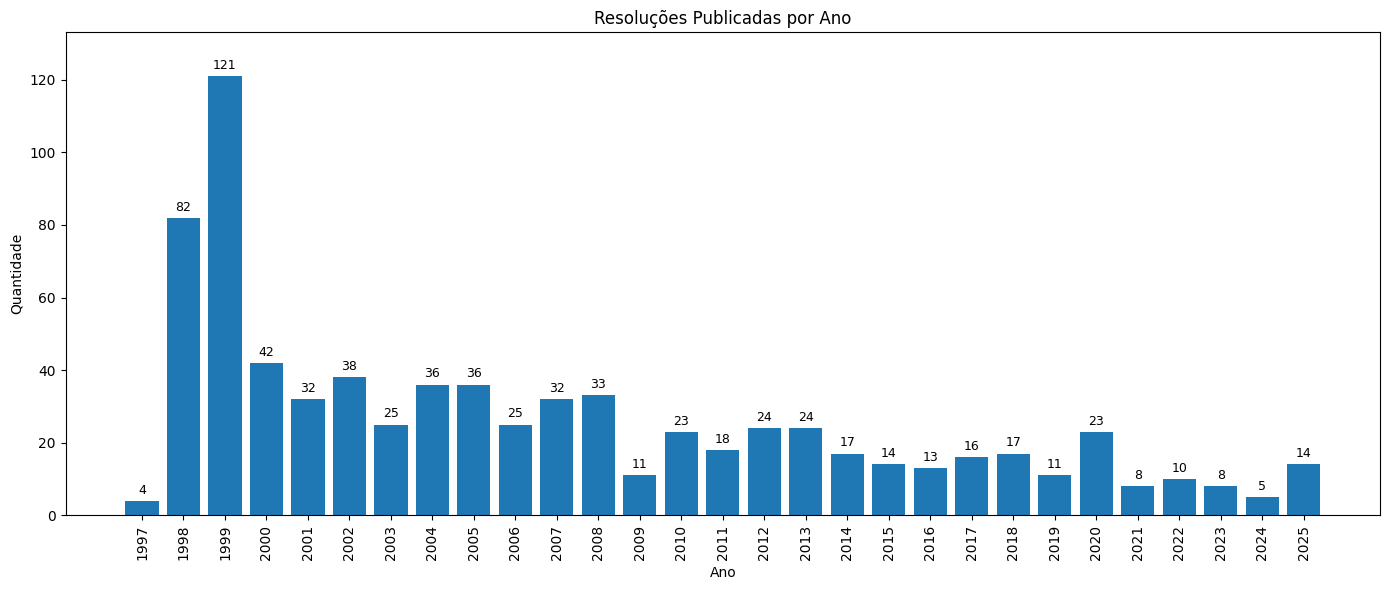

In [9]:
"""

Plotagem do gráfico de barrras de resoluções publicadas por ano.

"""

publicadas_ano = nodes_df["Ano"].value_counts()
publicadas_ano = (
    publicadas_ano
    .reindex(anos_completos, fill_value=0)
    .sort_index()
)

plt.figure(figsize=(14, 6))

# 1. Armazena as barras em uma variável
bars = plt.bar(publicadas_ano.index, publicadas_ano.values)

# 2. Adiciona os valores acima das colunas
plt.bar_label(bars, padding=3, fontsize=9)

plt.title("Resoluções Publicadas por Ano")
plt.xlabel("Ano")
plt.ylabel("Quantidade")

plt.ylim(0, publicadas_ano.max() * 1.1)

plt.xticks(anos_completos, rotation=90)
plt.tight_layout()
plt.show()

In [10]:
"""

Criação do dataframe com número de resoluções vigentes em cada ano.

"""
vigentes_lista = []

for ano in range(ano_min, ano_max + 1):

    total_vigentes = 0

    for indice, linha in nodes_df.iterrows():

        ano_publicacao = linha["Ano"]
        resolucao = linha["Resolução"]

        # Verificar se já foi publicada
        if ano_publicacao > ano:
            continue

        # Verificar se já foi revogada
        linha_destino = edges_df[edges_df["Origem"] == resolucao]

        #Caso não tenha sido revogada
        if linha_destino.empty:
            total_vigentes += 1
            
        #Caso tenha sido revogada
        else:
            resolucao_revogadora = linha_destino["Destino"].values[0]
            ano_revogacao = int(resolucao_revogadora.split("/")[0])

            if ano_revogacao > ano:
                total_vigentes += 1

    vigentes_lista.append({"Ano": ano, "Vigentes": total_vigentes})

vigentes_anualmente = pd.DataFrame(vigentes_lista)
        
        
    
            

In [11]:
print(vigentes_anualmente)

     Ano  Vigentes
0   1997         4
1   1998        86
2   1999       204
3   2000       241
4   2001       269
5   2002       293
6   2003       311
7   2004       341
8   2005       367
9   2006       382
10  2007       403
11  2008       430
12  2009       438
13  2010       454
14  2011       458
15  2012       474
16  2013       488
17  2014       500
18  2015       509
19  2016       518
20  2017       487
21  2018       496
22  2019       322
23  2020       275
24  2021       273
25  2022       184
26  2023       140
27  2024       128
28  2025        95


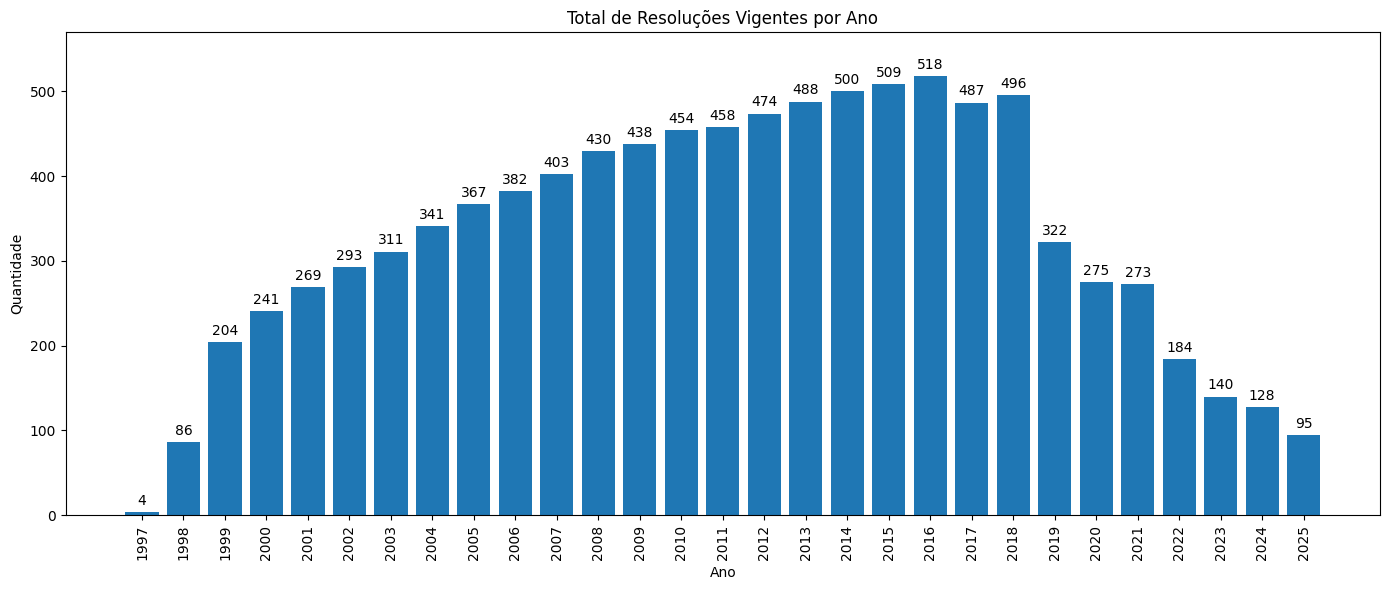

In [12]:
"""

Plotagem do gráfico de número de resoluções vigentes por ano

"""
plt.figure(figsize=(14,6))

bars = plt.bar(
    vigentes_anualmente["Ano"], 
    vigentes_anualmente["Vigentes"]
)

plt.bar_label(bars, padding=3)

plt.title("Total de Resoluções Vigentes por Ano")
plt.xlabel("Ano")
plt.ylabel("Quantidade")

plt.ylim(0, vigentes_anualmente["Vigentes"].max() * 1.1)

plt.xticks(
    vigentes_anualmente["Ano"], 
    rotation=90
)

plt.tight_layout()
plt.show()